<a href="https://colab.research.google.com/github/divyanshit11/Loan-Eligibility-Prediction/blob/main/Loan_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

Dataset Loading

In [3]:
from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data.csv


In [4]:
df = pd.read_csv('loan_data.csv')
df.head()

,Loan_ID,Gender,Married,ApplicantIncome,LoanAmount,Loan_Status
0,LP001002,Male,No,5849,NaN,Y
1,LP001003,Male,Yes,4583,128.0,N
2,LP001005,Male,Yes,3000,66.0,Y
3,LP001006,Male,Yes,2583,120.0,Y
4,LP001008,Male,No,6000,141.0,Y


Data Insights

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          598 non-null    object 
 1   Gender           598 non-null    object 
 2   Married          598 non-null    object 
 3   ApplicantIncome  598 non-null    int64  
 4   LoanAmount       577 non-null    float64
 5   Loan_Status      598 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 28.2+ KB


In [6]:
df.describe()

,ApplicantIncome,LoanAmount
count,598.000000,577.000000
mean,5292.252508,144.968804
std,5807.265364,82.704182
min,150.000000,9.000000
25%,2877.500000,100.000000
50%,3806.000000,127.000000
75%,5746.000000,167.000000
max,81000.000000,650.000000


Exploratory Data Analysis

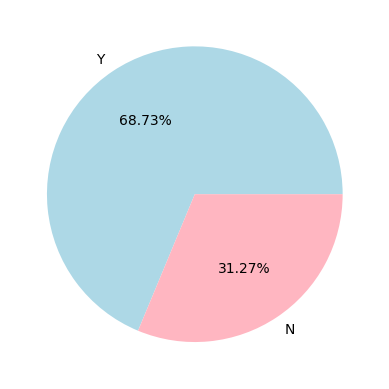

In [7]:
temp = df['Loan_Status'].value_counts()
plt.pie(temp.values, labels=temp.index, autopct='%1.2f%%', colors=['lightblue', 'lightpink'])
plt.show()

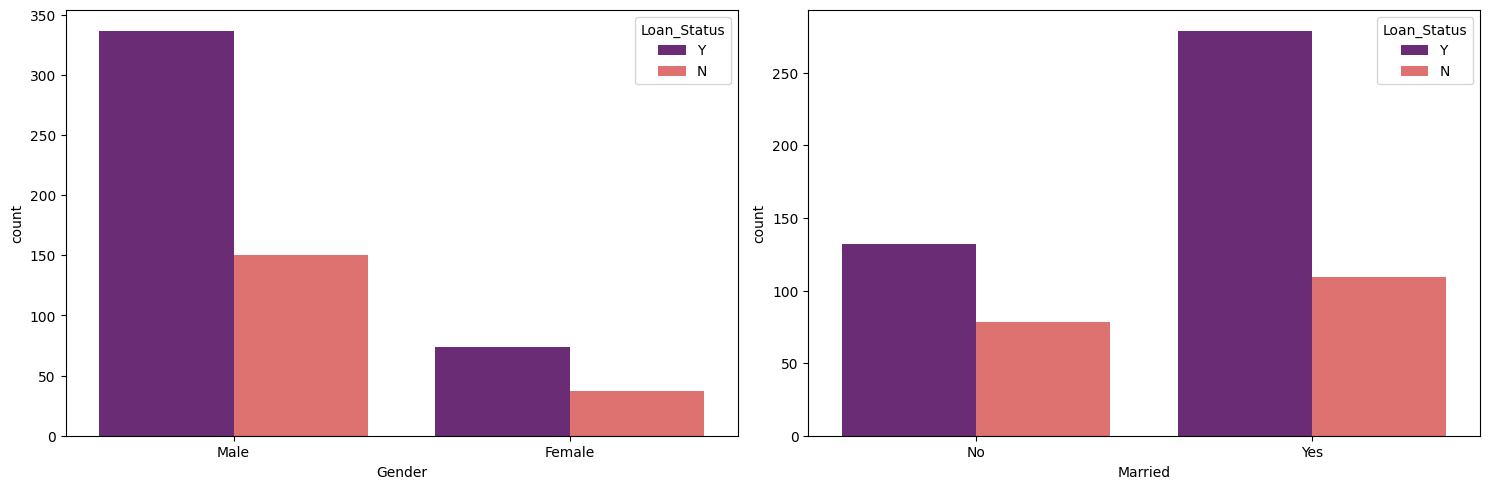

In [8]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['Gender','Married']):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=col, hue='Loan_Status', data=df, palette='magma')
plt.tight_layout()
plt.show()

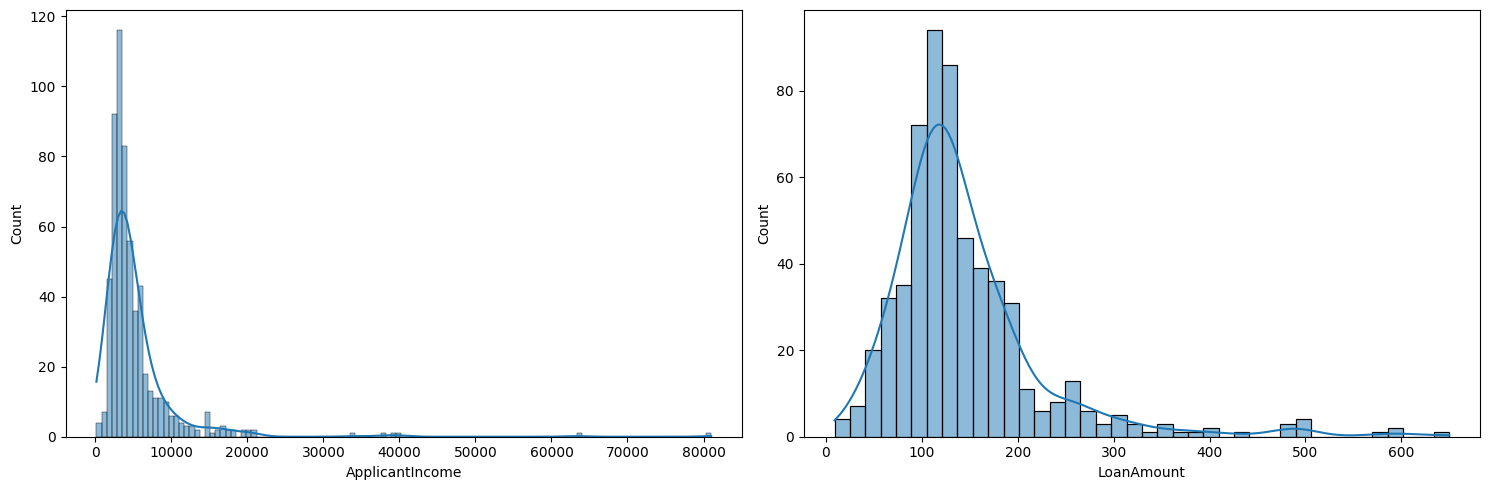

In [9]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['ApplicantIncome','LoanAmount']):
    plt.subplot(1, 2, i+1)
    sns.histplot(df[col], kde=True)
plt.tight_layout()
plt.show()

Dealing With Outliers

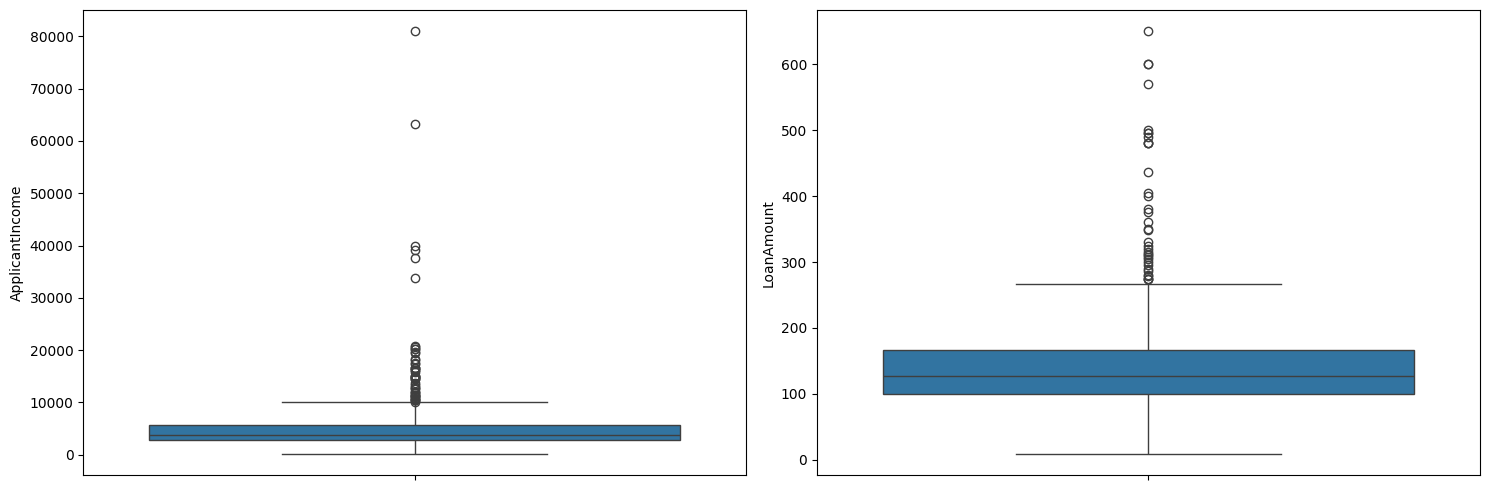

In [10]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['ApplicantIncome','LoanAmount']):
    plt.subplot(1, 2, i+1)
    sns.boxplot(df[col])
plt.tight_layout()
plt.show()

In [11]:
df = df[df['ApplicantIncome'] < 25000]
df = df[df['LoanAmount'] < 400]

In [12]:
df.groupby('Gender').mean(numeric_only=True)['LoanAmount']

,LoanAmount
Gender,
Female,118.822430
Male,139.289823


In [13]:
df.groupby(['Married','Gender']).mean(numeric_only=True)['LoanAmount']

Married  Gender
No       Female    116.115385
         Male      126.644628
Yes      Female    126.103448
         Male      143.912387
Name: LoanAmount, dtype: float64

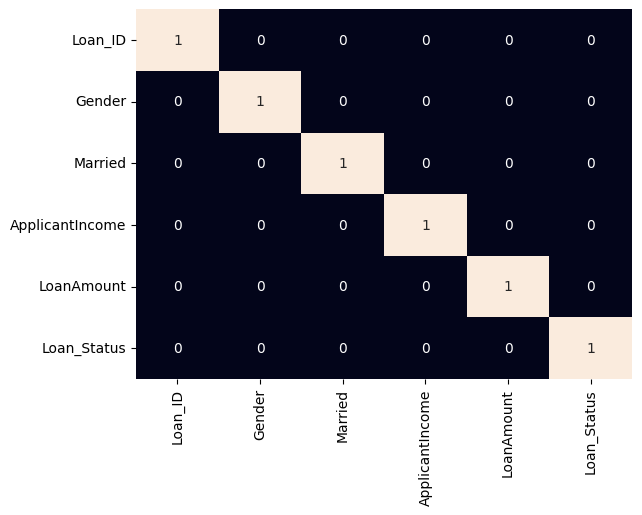

In [14]:
def encode_labels(df):
  for col in df.columns:
    if df[col].dtype == 'object':
      le = LabelEncoder()
      df[col] = le.fit_transform(df[col])
  return df

df = encode_labels(df)
sns.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()

Data Preprocessing

In [15]:
features = df.drop('Loan_Status', axis=1)
target = df['Loan_Status']

X_train, X_val, Y_train, Y_val = train_test_split(features,
                                  target, test_size=0.2, random_state=10)

ros = RandomOverSampler( sampling_strategy='minority',random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X_train.shape, X.shape

((447, 5), (616, 5))

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

Model Development

In [17]:
from sklearn.metrics import roc_auc_score
model = SVC(kernel='rbf')
model.fit(X, Y)

print('Training Accuracy : ', metrics.roc_auc_score(Y, model.predict(X)))
print('Validation Accuracy : ', metrics.roc_auc_score(Y_val, model.predict(X_val)))
print()

Training Accuracy :  0.547077922077922
Validation Accuracy :  0.5



Model Evaluation

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
training_roc_auc = roc_auc_score(Y, model.predict(X))
validation_roc_auc = roc_auc_score(Y_val, model.predict(X_val))
print('Training ROC AUC Score:', training_roc_auc)
print('Validation ROC AUC Score:', validation_roc_auc)
print()
cm = confusion_matrix(Y_val, model.predict(X_val))

Training ROC AUC Score: 0.547077922077922
Validation ROC AUC Score: 0.5



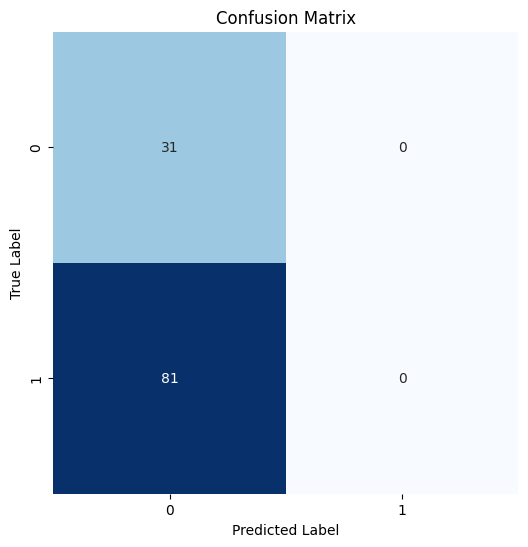

In [20]:
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [21]:
from sklearn.metrics import classification_report
print(classification_report(Y_val, model.predict(X_val)))

              precision    recall  f1-score   support

           0       0.28      1.00      0.43        31
           1       0.00      0.00      0.00        81

    accuracy                           0.28       112
   macro avg       0.14      0.50      0.22       112
weighted avg       0.08      0.28      0.12       112

